# Contact Map

Generate ground truth contact map from PDB structure (C-alpha distances).

In [13]:
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [14]:
def parse_pdb_ca(pdb_path):
    """Extract C-alpha coordinates from PDB file."""
    coords = []
    residues = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                x = float(line[30:38])
                y = float(line[38:46])
                z = float(line[46:54])
                res_num = int(line[22:26])
                coords.append([x, y, z])
                residues.append(res_num)
    return np.array(coords), residues

In [15]:
def compute_contact_map(coords, threshold=8.0):
    """Compute contact map from C-alpha coordinates."""
    diff = coords[:, None, :] - coords[None, :, :]
    distances = np.sqrt((diff ** 2).sum(axis=-1))
    contacts = (distances < threshold).astype(float)
    np.fill_diagonal(contacts, 0)
    return contacts, distances

## Load PDB

In [16]:
PDB_PATH = "AF-P0AA25-F1-model_v6.pdb"
MSA_PATH = "AF-P0AA25-F1-msa_v6.npz"

coords, residues = parse_pdb_ca(PDB_PATH)
print(f"Parsed {len(coords)} C-alpha atoms")
print(f"Residues: {min(residues)} to {max(residues)}")

msa = np.load(MSA_PATH)
non_gap = msa["non_gap"]
print(f"Non-gap positions from MSA: {len(non_gap)}")

Parsed 109 C-alpha atoms
Residues: 1 to 109
Non-gap positions from MSA: 101


## Compute Contact Map

In [17]:
contacts_full, distances_full = compute_contact_map(coords, threshold=8.0)
print(f"Full contact map: ({contacts_full.shape[0]}, {contacts_full.shape[1]})")

contacts = contacts_full[non_gap][:, non_gap]
distances = distances_full[non_gap][:, non_gap]
L = contacts.shape[0]

# Apply sequence separation filter (|i-j| > 5)
# Removes trivial backbone contacts, keeps long-range contacts
sep = np.abs(np.arange(L)[:, None] - np.arange(L)[None, :])
contacts = contacts * (sep > 5)

n_contacts = int(contacts.sum() / 2)
print(f"Subsetted contact map: ({L}, {L})")
print(f"Total contacts (|i-j| > 5): {n_contacts}")

Full contact map: (109, 109)
Subsetted contact map: (101, 101)
Total contacts (|i-j| > 5): 156


## Visualization

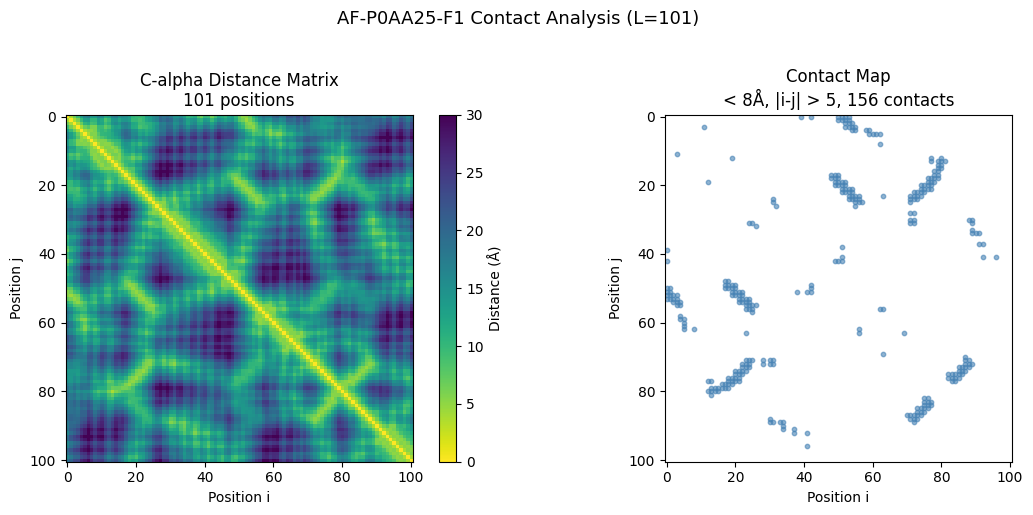

In [18]:
# Enhanced visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Distance matrix (heatmap)
im0 = axes[0].imshow(distances, cmap="viridis_r", vmin=0, vmax=30)
axes[0].set_xlabel("Position i")
axes[0].set_ylabel("Position j")
axes[0].set_title(f"C-alpha Distance Matrix\n{L} positions")
plt.colorbar(im0, ax=axes[0], label="Distance (Å)")

# Panel 2: Contact map (scatter plot - cleaner than heatmap for binary data)
triu_idx = np.triu_indices_from(contacts, 1)
contact_idx = contacts[triu_idx] > 0
axes[1].scatter(triu_idx[0][contact_idx], triu_idx[1][contact_idx], 
                c="steelblue", s=10, alpha=0.6)
axes[1].scatter(triu_idx[1][contact_idx], triu_idx[0][contact_idx], 
                c="steelblue", s=10, alpha=0.6)
axes[1].set_xlim(-0.5, L - 0.5)
axes[1].set_ylim(L - 0.5, -0.5)
axes[1].set_aspect("equal")
axes[1].set_xlabel("Position i")
axes[1].set_ylabel("Position j")
axes[1].set_title(f"Contact Map\n< 8Å, |i-j| > 5, {n_contacts} contacts")

plt.suptitle(f"AF-P0AA25-F1 Contact Analysis (L={L})", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Save

In [19]:
from pathlib import Path
out_path = Path(PDB_PATH).stem + "_contacts.npz"
np.savez(out_path, contacts=contacts, distances=distances, non_gap=non_gap)
print(f"Saved to {out_path}")

Saved to AF-P0AA25-F1-model_v6_contacts.npz
